[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/wavy_channel.ipynb)


# LEARNING OBJECTIVE

This notebook shows how to calculate the pressure drop along a rigid wavy channel, given the inlet flow rate, using lubrication theory.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [66]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *
from IPython.display import display, Math

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
import matplotlib.patches as patches
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np
from scipy.integrate import quad

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

Adapted from Panton's _Incompressible Flow_, 4th ed., Prob. 22.1 (B).

# FLOW IN A WAVY CHANNEL

Find the pressure drop due to steady, low-Reynolds-number, pressure-driven flow in a wavy channel, $0<y<h(x)$, where $h(x) = h_0 + A \sin(2\pi x/L)$, using lubrication theory.

## Governing equations

The dimensional lubrication equations are
\begin{alignat*}{3}
    \text{[COM]}\qquad &&\frac{\partial v_x}{\partial x} + \frac{\partial v_y}{\partial y} &= 0,\\
    \text{[COLM-$x$]}\qquad &&0 &\approx -\frac{\partial p}{\partial x} + \mu \frac{\partial^2 v_x}{\partial y^2},\\
    \text{[COLM-$y$]}\qquad &&0 &\approx -\frac{\partial p}{\partial y}.
\end{alignat*}
The boundary conditions (no slip, no penetration, and given inlet/outlet pressure) are
\begin{align*}
    v_x(x,y=0) &= 0,\\
    v_y(x,y=0) &= 0.\\
    v_x\big(x,y=h(x)\big) &= 0,\\
    v_y\big(x,y=h(x)\big) &= 0,\\
    p(x=0,y) &= p_\mathrm{in},\\
    p(x=L,y) &= p_\mathrm{out}.
\end{align*}

## The horizontal velocity

The solution of COLM-$y$ subject to these boundary conditions is easily shown to be Poiseuille flow, but with $h=h(x)$:
$$
    v_x(x,y) = \frac{[h(x)]^2}{2\mu}\left(-\frac{\partial p}{\partial x}\right) \left\{ \frac{y}{h(x)} - \left[\frac{y}{h(x)}\right]^2 \right\},
$$
where the pressure $p(x)$ is currently unknown. We'll keep using partial derivatives for clarity, but most quantities are only functions of $x$.

From the velocity, we can calculate the flow rate across any vertical cross-section:
$$
    Q = \int_0^{h(x)} v_x(x,y) \,dy =  - \frac{[h(x)]^3}{12\mu} \frac{\partial p}{\partial x} .
$$

## The vertical velocity

Integrating COM from $0$ to some arbitrary $y$ and using the boundary condition, we get
\begin{align*}
  \int_0^y \frac{\partial v_y}{\partial \tilde{y}} d\tilde{y} =
  v_y(x,y) - \underbrace{v_y(x,y=0)}_{0} &\,\,\overbrace{=}^{\text{COM}}  - \int_0^{y} \frac{\partial v_x}{\partial x} \,d\tilde{y} \\
  &= - \frac{\partial}{\partial x} \int_0^{y} v_x(x,\tilde{y}) \,d\tilde{y} \\
  &= - \frac{\partial}{\partial x} \left( \frac{[h(x)]^2}{2\mu}\left(-\frac{\partial p}{\partial x}\right) \left\{ \frac{y^2}{2h(x)} - \frac{y^3}{3[h(x)]^2} \right\} \right).
\end{align*}

## The pressure drop

Imposing the no-penetration condition (vertical component of the no-slip condition) on $v_y$ at $y=h(x)$  from the last subsection, we have
\begin{align*}
  v_y\big(x,y=h(x)\big) = 0 
  &= - \frac{\partial}{\partial x} \Bigg[ \frac{[h(x)]^2}{2\mu} \left(-\frac{\partial p}{\partial x}\right) \left\{ \frac{h(x)}{2} - \frac{h(x)}{3} \right\} \Bigg] \\
  &= - \frac{\partial}{\partial x} \Bigg[ \underbrace{-\frac{[h(x)]^3}{12\mu} \frac{\partial p}{\partial x}}_{Q} \Bigg] \\
\end{align*}
from which we learn that the flow rate is _constant everywhere_; the inlet $Q$ is maintained at **any** $x$ in the channel.

Thus, 
$$
    -\frac{[h(x)]^3}{12\mu}\frac{\partial p}{\partial x} = Q = const.,
$$
and we can separate and integrate from $x=0$ to $x=L$:
$$
    \underbrace{p(x=L) - p(x=0)}_{p_\mathrm{out} - p_\mathrm{in} = -\Delta p} = - 12 \mu Q \int_0^L \frac{1}{[h(x)]^3} dx.
$$
Hence,
\begin{align*}
   \frac{\Delta p}{L} &= \frac{12 \mu Q}{L} \int_0^L \frac{dx}{[h(x)]^3} \\
                      &= \frac{12 \mu Q}{h_0^3} \int_0^1 \frac{dx^*}{[h^*(x^*)]^3},
\end{align*}
where the dimensionless channel shape is 
$$
    h^*(x^*) = \frac{h(x)}{h_0} = 1 + \frac{A}{h_0} \sin(2\pi x^*).
$$

Note that the channel _cannot close_, thus we need to ensure that $|A/h_0| < 1$.

# PRESSURE DROP GIVEN CHANNEL SHAPE

Calculating $\Delta p$ boils down to evaluating an integral, since we've shown that
$$
    \frac{\Delta p/L}{\mu Q/h_0^3} = 12\int_0^1 \frac{dx^*}{[h^*(x^*)]^{3}}.
$$
Notice that 
$$
    \frac{\Delta p/L}{\mu Q/h_0^3} = \frac{\Delta p}{\mu Q L/h_0^3},
$$
and $\mu Q L/h_0^3$ is _precisely_ the pressure scale used to derive the governing equations of lubrication theory!

Note that $\Delta p/Q$ is sometimes called the _flow resistance_, so $\Delta p/(\mu Q L/h_0^3)$ is the _dimensionless flow resistance_.

Let's set the wavy channel shape.

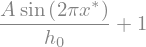

In [67]:
# defining symbols
xs, ys, A, h0 = sp.symbols('x^*, y^*, A, h_0')

# getting a little fancy with the printing of Aoverh0 ratio
Aoverh0 = sp.symbols('(A/h_{0})')

hs = 1 + A/h0*sp.sin(2*sp.pi*xs)
hs

Let's try to evaluate $\int_0^1 \frac{dx^*}{[h^*(x^*)]^{3}}$.

It may or may not be possible to evalaute the integral analytically for arbitrary $h^*(x^*)$, ...

In [68]:
# sp.integrate(1/hs**3, (xs, 0, 1))

But we can do it numerically. 

So, we [`lambdify`](https://docs.sympy.org/latest/modules/utilities/lambdify.html) our function for evaluation and plotting.

In [69]:
# without loss of generality set h0 = 1,
# and set A to the ratio A/h0, which we will vary
hs_func = sp.lambdify((xs, Aoverh0), hs.subs(h0, 1).subs(A, Aoverh0), 'numpy')

Since $h^*(x^*)$ is given analytically, we can use SciPy's [`quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html), instead of `trapezoid`, to get a highly accurate evaluation.

In [70]:
# to evaluate the integral requires one more lambidification
# to substitute the value of A/h0 (= 0.5 in this example)
quad(lambda x: 12/hs_func(x, 0.5)**3, 0, 1)

 The first number in the output is the integral's value. The second number is the error estimate. Looks accurate!

## Visualization

### The channel shape

Let's plot the shape for different $A/h_0$ values.

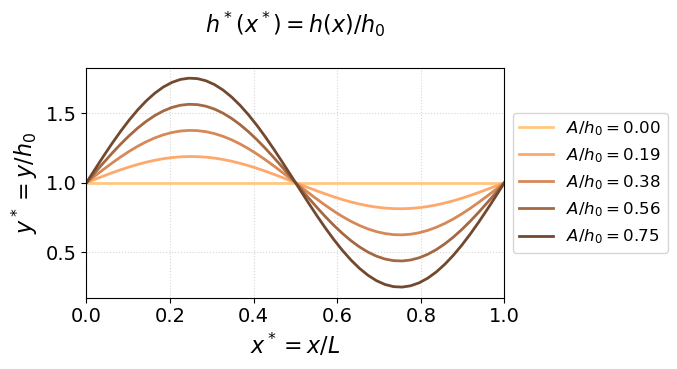

In [71]:
fig, ax = plt.subplots(tight_layout=True, figsize=(7, 5))

# sequential colormap with gradient that looks nice
# https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential
cmap = colormaps['copper_r']

# A/h_0 from 0 to whatever you want
Aoh0 = np.linspace(0, 0.75, num=5)
# x^* goes from 0 to 1
xsp = np.linspace(0, 1)

# Loop over A/h0 values and plot h(x) for each
for i, tmp in enumerate(Aoh0):
    hsp = 0*xsp

    for j, x in enumerate(xsp):
        hsp[j] = hs.subs({xs: x, A: tmp, h0: 1})

    # argument from 0 to 1; with a little scaling
    randcol = cmap(i/(1.25*len(Aoh0)))
    ax.plot(xsp, hsp, 
            linewidth=2, color=randcol, label=f'$A/h_0 = {tmp:.2f}$')

ax.set_xlabel('$x^* = x/L$')
ax.set_xlim(0, 1)
ax.set_ylabel(r'$y^* = y/h_0$')

ax.set_title('$h^*(x^*) = h(x)/h_0$')

# show a grid to make it easier to see where the y=0 interface is
ax.grid(alpha=0.5, linestyle='dotted')

ax.set_aspect(1 / 3)

# move legend off the plot because it is too long
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

### The pressure drop

It is actually the dimensionles flow resistance, as discussed above.

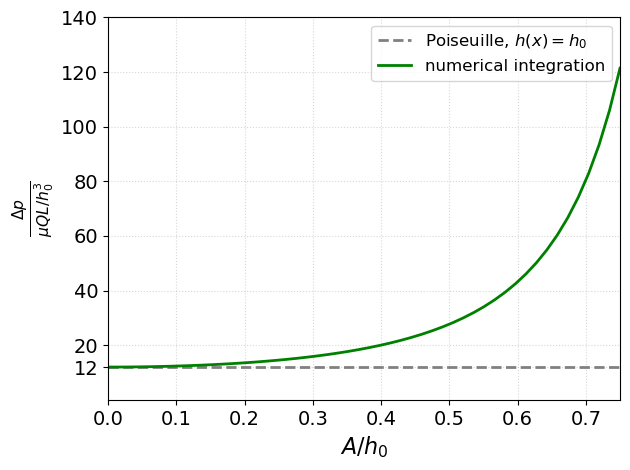

In [84]:
# A/h_0 from 0 to whatever you want
Aoh0 = np.linspace(0, 0.75)
dp = Aoh0*0  # placeholder for pressure drop values

# Evaluate pressure drop for each A/h0
for i, tmp in enumerate(Aoh0):
    dp[i] = quad(lambda x: 12/hs_func(x, tmp)**3, 0, 1)[0]

fig, ax = plt.subplots(tight_layout=True)

ax.plot(Aoh0, 12*np.ones_like(Aoh0), linestyle='dashed',
        linewidth=2, color='gray', label=r'Poiseuille, $h(x) = h_0$')
ax.plot(Aoh0, dp, 
        linewidth=2, color='green', label='numerical integration')

# customize y-ticks to show 12
yticks = ax.get_yticks()
new_tick = 12
# delete any existing ticks below new_tick, which is the lowest value we want
yticks = yticks[yticks > new_tick]
# add 12 tick
yticks = np.append(yticks, new_tick)
yticks = np.sort(yticks)
ax.set_yticks(yticks)

ax.set_ylabel(r'$\frac{\Delta p}{\mu Q L/h_0^3}$')
ax.set_ylim(bottom=0)
ax.set_xlabel('$A/h_0$')
ax.set_xlim(0, Aoh0.max())

# show a grid to make it easier to see where the y=0 interface is
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

plt.show()

We learn that maintaining the same flow rate $Q$ in a wavy channel takes a _larger_ pressure drop than in a straight channel (Hagen&ndash;Poiseuille law). The pressure drop increase also shoots up dramatically as $A/h_0$ increases (that is, as the channel becomes more constricted somewhere).

### The velocity field

First, we need to define the velocity components symbolically from our formulas above; the expressions are a bit ugly.

In [73]:
# define the symoblic pressure grad and vel components
# all dimensionless
dpsdxs = -12/hs**3
vxs = (hs**2)/2*(-dpsdxs)*(ys/hs - (ys/hs)**2)
vys = -((hs**2)/2*(-dpsdxs)*((ys**2)/(2*hs) - (ys**3)/(3*hs**2))).diff(xs)

Next, we check our work symbolically with SymPy.

In [74]:
# check BCs on symbolic expressions
# got a little fancy with display Math here ...
display(Math(r'\text{checking}~~~~v_x^*~\text{at}~y^*=0~~~~~~:~' +
             sp.latex(vxs.subs(ys, 0))))
display(Math(r'\text{checking}~~~~v_x^*~\text{at}~y^*=h^*~~~~:~' +
             sp.latex(vxs.subs(ys, hs))))
display(Math(r'\text{checking}~~~~v_y^*~\text{at}~y^*=0~~~~~~:~' +
             sp.latex(vys.subs(ys, 0))))
display(Math(r'\text{checking}~~~~v_y^*~\text{at}~y^*=h^*~~~~:~' +
             sp.latex(vys.subs(ys, hs).simplify())))
# check COM with symbolic expressions
display(Math(r'\text{checking}~~~~\frac{\partial v_x^*}{\partial x^*}' +
             r'+\frac{\partial v_y^*}{\partial y^*}~~~~~~~:~' +
             sp.latex((vxs.diff(xs) + vys.diff(ys)).simplify())))
# check COLM with symbolic expressions
display(Math(r'\text{checking}~~~~-\frac{\partial p^*}{\partial x^*}' +
             r'+\frac{\partial^2 v_x^*}{\partial y^{*2}}:~' +
             sp.latex((-dpsdxs + vxs.diff(ys, 2)).simplify())))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Finally, we [`lambdify`](https://docs.sympy.org/latest/modules/utilities/lambdify.html) our functions for evaluation and plotting.

In [75]:
lam_vx = sp.lambdify((xs, ys, Aoverh0), vxs.subs(
    h0, 1).subs(A, Aoverh0), 'numpy')
lam_vy = sp.lambdify((xs, ys, Aoverh0), vys.subs(
    h0, 1).subs(A, Aoverh0), 'numpy')

In [76]:
def plot_func_vel(Aoh0):
    xp, yp = np.meshgrid(np.linspace(0, 1, num=8),
                         np.linspace(0, 2, num=25))
    qs = 15  # scaling factor for quiver plot

    # y^* goes from 0 to h^* but we'll mask the values > h^* later
    mask = yp > hs_func(xp, Aoh0)

    vx = np.ma.masked_array(lam_vx(xp, yp, Aoh0), mask)
    vy = np.ma.masked_array(lam_vy(xp, yp, Aoh0), mask)

    fig, ax = plt.subplots(tight_layout=True)

    ax.set_ylabel('$y^* = y/h_0$')
    ax.set_ylim(0, 1.75)
    ax.set_xlabel('$x^* = x/L$')
    ax.set_xlim(0, 1)

    ax.quiver(xp, yp, vx, vy,
              scale=qs, scale_units='xy', color='blue', zorder=2)

    # show the wavy wall
    xpp = np.linspace(0, 1)
    ax.plot(xpp, hs_func(xpp, Aoh0), 
            linewidth=4, color='black')

    # show a grid
    ax.grid(alpha=0.5, linestyle='dotted')

    plt.show()

First, a static plot.

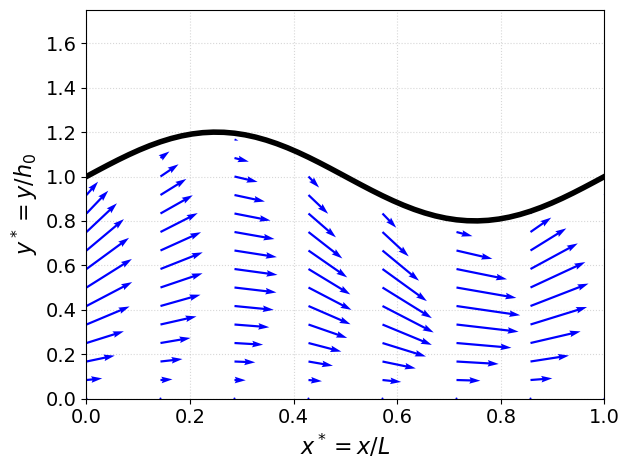

In [77]:
plot_func_vel(0.2)

Next, an [`interact`](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html) widget will let us vary $A/h_0$.

In [78]:
interact(plot_func_vel, 
         Aoh0=widgets.FloatSlider(value=0.2, min=0.01, max=0.75, step=0.1, description='ampl. A/h0'));

## Approximate pressure drop solution for $A/h_0\ll1$

We can make some analytical progress with $\int_0^1 \frac{dx^*}{[h^*(x^*)]^{3}}$ if the wavyness is "small", specifically $A/h_0 \ll 1$. 

To this end, expand the integrand for small $A/h_0 \ll 1$:

In [79]:
integrand_series = sp.series(1/hs.subs(h0, 1).subs(A, Aoverh0)**3, Aoverh0, 0, 3)
integrand_series

In [80]:
# removeO to get rid of the big-O remainder and integrate the first few terms
dp_correction = sp.integrate(integrand_series.removeO(), (xs, 0, 1))
dp_correction

Thus, 
$$
    \frac{\Delta p}{L} \approx  \frac{12 \mu Q }{h_0^3} \left[ 1 + 3 \left(\frac{A}{h_0}\right)^2 + \cdots \right].
$$
We recognize the "$1$" in the brackets as the term due to Poiseuille flow in a channel of constant height $h_0$, and the "$3(A/h_0)^2$" as the correction due to the wavy nature of this channel.


Let's see how this approximation does compared to the numerical result.

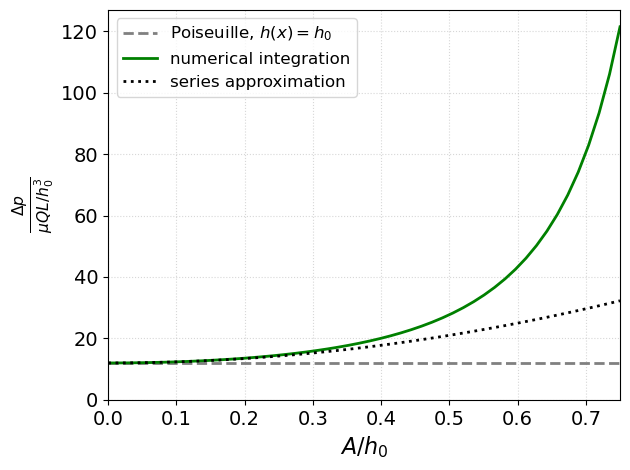

In [83]:
# A/h_0 from 0 to whatever you want
Aoh0 = np.linspace(0, 0.75)

# placeholders for pressure drop values
dp = Aoh0*0
dp_approx = Aoh0*0

# Evaluate pressure drop for each A/h0
for i, tmp in enumerate(Aoh0):
    dp[i] = quad(lambda x: 12/hs_func(x, tmp)**3, 0, 1)[0]
    dp_approx[i] = 12*dp_correction.subs(Aoverh0, tmp)

fig, ax = plt.subplots(tight_layout=True)

ax.plot(Aoh0, 12*np.ones_like(Aoh0), linestyle='dashed',
        linewidth=2, color='gray', label=r'Poiseuille, $h(x) = h_0$')
ax.plot(Aoh0, dp,
        linewidth=2, color='green', label='numerical integration')
ax.plot(Aoh0, dp_approx,
        linewidth=2, linestyle='dotted', color='black', label='series approximation')

ax.set_ylabel(r'$\frac{\Delta p}{\mu Q L/h_0^3}$')
ax.set_ylim(bottom=0)
ax.set_xlabel('$A/h_0$')
ax.set_xlim(0, Aoh0.max())

ax.legend()

# show a grid to make it easier to see where the y=0 interface is
ax.grid(alpha=0.5, linestyle='dotted')

plt.show()

# FURTHER EXPLORATION

On your own:

*   Try to keep more terms in the series approximation of $h^*(x^*)$ to get the next correction to the pressure drop (and check its accuracy).
*   Make the wall "more wavy" by replacing $\sin(2\pi x/L)$ with $\sin(2\pi n x/L)$ for some integer $n>1$.
*   Compute $p(x)$ in the wavy channel and compare it to the liner Hagen&ndash;Poiseuille pressure profile.
    -   For an extra challenge, add the pressure as a filled contour plot in the background of the velocity figure.